In [2]:
# Data Handling
import pandas as pd
import numpy as np

import warnings

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


warnings.filterwarnings('ignore')


pd.set_option('display.max_columns', None)

# House Price Prediction using Machine Learning

## Objective
The goal of this project is to develop machine learning models capable of predicting house prices based on various property characteristics such as area, number of bedrooms, bathrooms, furnishing status, and location-related features.

## Task 1: Data Loading and Exploration
In this section, the dataset is loaded and explored to understand its structure, feature types, missing values, and overall data quality before proceeding to preprocessing and model development.

In [3]:
df = pd.read_csv("Housing.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [4]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [5]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 545
Number of Columns: 13


In [6]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')


In [7]:
target = "price"

features = df.drop("price", axis=1).columns

print("Target Variable:")
print(target)

print("\nFeature Variables:")
print(list(features))

Target Variable:
price

Feature Variables:
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [9]:
#check for missing values
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [10]:
#duplicate rows check
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [11]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## Task 2: Data Cleaning and Feature Engineering

The dataset was inspected for missing values and duplicate records. No missing values or duplicate rows were found. Categorical variables were converted into numerical form to make them suitable for machine learning algorithms.

In [12]:
df.dtypes

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

In [13]:
#viewing unique value of categorical columns

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


mainroad
<StringArray>
['yes', 'no']
Length: 2, dtype: str

guestroom
<StringArray>
['no', 'yes']
Length: 2, dtype: str

basement
<StringArray>
['no', 'yes']
Length: 2, dtype: str

hotwaterheating
<StringArray>
['no', 'yes']
Length: 2, dtype: str

airconditioning
<StringArray>
['yes', 'no']
Length: 2, dtype: str

prefarea
<StringArray>
['yes', 'no']
Length: 2, dtype: str

furnishingstatus
<StringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str


In [14]:
#convert categorical column to numerical
# it's one-hot encoding
df_encoded = pd.get_dummies(
    df,
    columns=['furnishingstatus'],
    drop_first=True
)

In [15]:
#convert yes/no column

binary_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_columns:
    df_encoded[col] = df_encoded[col].map({
        'yes': 1,
        'no': 0
    })

In [16]:
#verifying cleaned dataset

df_encoded.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [17]:
df_encoded.dtypes

price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
dtype: object

In [18]:
#converting bool columns to int
bool_cols = df_encoded.select_dtypes(include='bool').columns

df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

df_encoded.dtypes

print("Original Shape:", df.shape)
print("Encoded Shape:", df_encoded.shape)

Original Shape: (545, 13)
Encoded Shape: (545, 14)


In [19]:
#saving this cleaned dataset to a new CSV file

df_encoded.to_csv("Housing_Cleaned.csv", index=False)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


In [20]:
#once checking the shape of cleaned dataset

df_encoded.shape

(545, 14)

## Task 3: Model Building

In this section, machine learning models are trained to predict house prices. Two regression algorithms are used:

1. Linear Regression
2. Random Forest Regressor

The performance of both models is evaluated using:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [21]:
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (545, 13)
Target Shape: (545,)


In [22]:
# Splitting the  Data into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (436, 13)
Testing Data: (109, 13)


In [23]:
#now firstly training linear regression model

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [24]:
# making predictions with linear regression model
lr_predictions = lr_model.predict(X_test)

In [25]:
#evaluating linear regression model

lr_mae = mean_absolute_error(y_test, lr_predictions)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_predictions)
)

lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Results")
print("-" * 30)

print("MAE :", round(lr_mae, 2))
print("RMSE:", round(lr_rmse, 2))
print("R² Score:", round(lr_r2, 4))

Linear Regression Results
------------------------------
MAE : 970043.4
RMSE: 1324506.96
R² Score: 0.6529


In [26]:
# training random forest regressor model

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [27]:
# Random Forest Predictions

rf_predictions = rf_model.predict(X_test)

In [28]:
# Evaluate Random Forest

rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("-" * 30)

print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R² Score:", round(rf_r2, 4))

Random Forest Results
------------------------------
MAE : 1014947.32
RMSE: 1399769.44
R² Score: 0.6124


In [29]:
# comparing both the models

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse
    ],
    "R2 Score": [
        lr_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.014947e+06,1.399769e+06,0.612360


In [30]:
# highlighting the best model

best_model = comparison.loc[
    comparison["R2 Score"].idxmax()
]

print("Best Performing Model")
print(best_model)

Best Performing Model
Model       Linear Regression
MAE              970043.40392
RMSE           1324506.960091
R2 Score             0.652924
Name: 0, dtype: object


In [31]:
# Add Feature Scaling for Linear Regression to check if it improves performance

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_scaled = LinearRegression()

lr_scaled.fit(X_train_scaled, y_train)

scaled_predictions = lr_scaled.predict(X_test_scaled)

scaled_mae = mean_absolute_error(y_test, scaled_predictions)
scaled_rmse = np.sqrt(mean_squared_error(y_test, scaled_predictions))
scaled_r2 = r2_score(y_test, scaled_predictions)

print("Scaled Linear Regression")
print("-------------------------")
print("MAE :", round(scaled_mae, 2))
print("RMSE:", round(scaled_rmse, 2))
print("R² Score:", round(scaled_r2, 4))

# trying to tune random forest 

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Improved Random Forest")
print("----------------------")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R² Score:", round(rf_r2, 4))


# Scaled Linear Regression
# -------------------------
# MAE : 970043.4
# RMSE: 1324506.96
# R² Score: 0.6529

Scaled Linear Regression
-------------------------
MAE : 970043.4
RMSE: 1324506.96
R² Score: 0.6529
Improved Random Forest
----------------------
MAE : 1030661.85
RMSE: 1411474.24
R² Score: 0.6058


In [32]:
# trying to tune random forest 

# rf_model = RandomForestRegressor(
#     n_estimators=500,
#     max_depth=10,
#     min_samples_split=5,
#     random_state=42
# )

# rf_model.fit(X_train, y_train)

# rf_predictions = rf_model.predict(X_test)

# rf_mae = mean_absolute_error(y_test, rf_predictions)
# rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
# rf_r2 = r2_score(y_test, rf_predictions)

# print("Improved Random Forest")
# print("----------------------")
# print("MAE :", round(rf_mae, 2))
# print("RMSE:", round(rf_rmse, 2))
# print("R² Score:", round(rf_r2, 4))

# this made it worse so stick with the previous random forest model
# Improved Random Forest
# ----------------------
# MAE : 1030661.85
# RMSE: 1411474.24
# R² Score: 0.6058

In [33]:
# comparison table

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})

comparison = comparison.sort_values(
    by="R2 Score",
    ascending=False
)

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.030662e+06,1.411474e+06,0.605850


# task 4
making a charts folder for storing visualizations

In [34]:
# task 4
#making a charts folder for storing visualizations

import os

os.makedirs("charts", exist_ok=True)

print("Charts folder ready!")

Charts folder ready!


### Chart 1: Distribution of House Prices

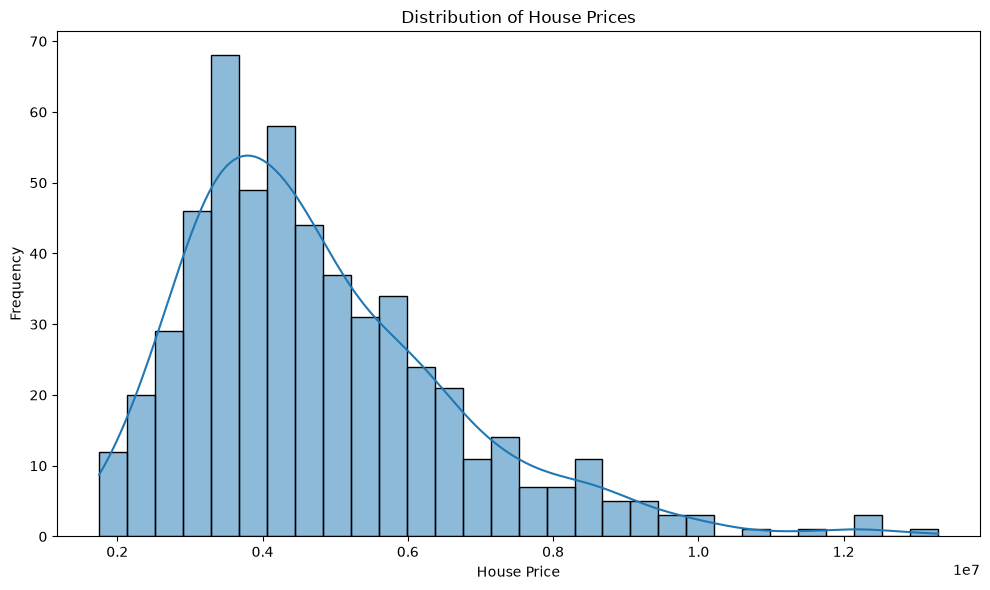

In [35]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["price"],
    bins=30,
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("charts/price_distribution.png", dpi=300)

plt.show()

### Chart 2: Correlation Heatmap

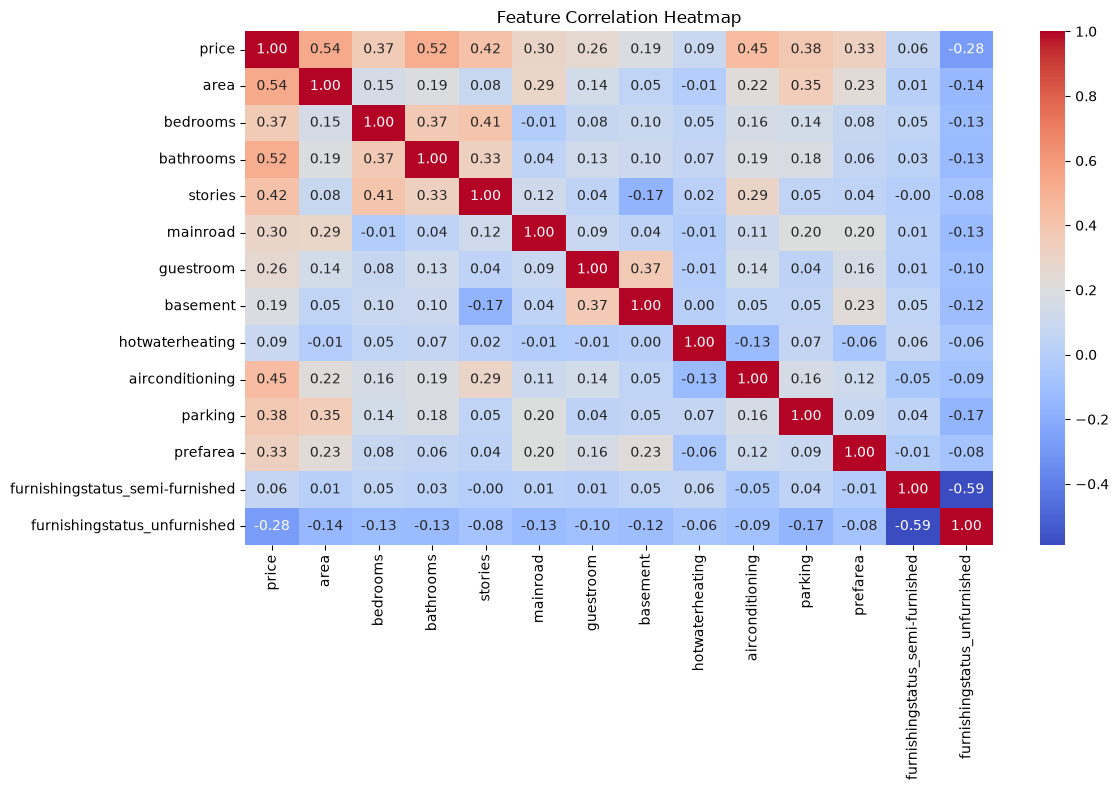

In [36]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_encoded.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()

plt.savefig("charts/correlation_heatmap.png", dpi=300)

plt.show()

### Chart 3: Actual vs Predicted House Prices

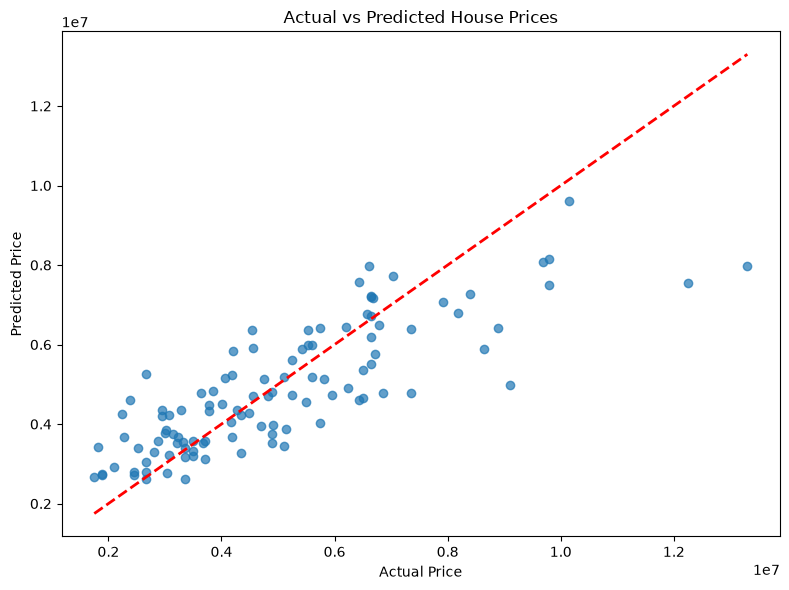

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    lr_predictions,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.tight_layout()

plt.savefig("charts/actual_vs_predicted.png", dpi=300)

plt.show()

### Feature Importance Analysis

In [38]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": abs(lr_model.coef_)
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
2,bathrooms,1.094445e+06
8,airconditioning,7.914267e+05
7,hotwaterheating,6.846499e+05
10,prefarea,6.298906e+05
12,furnishingstatus_unfurnished,4.136451e+05
3,stories,4.074766e+05
6,basement,3.902512e+05
4,mainroad,3.679199e+05
5,guestroom,2.316100e+05
9,parking,2.248419e+05


### Plot Feature Importance

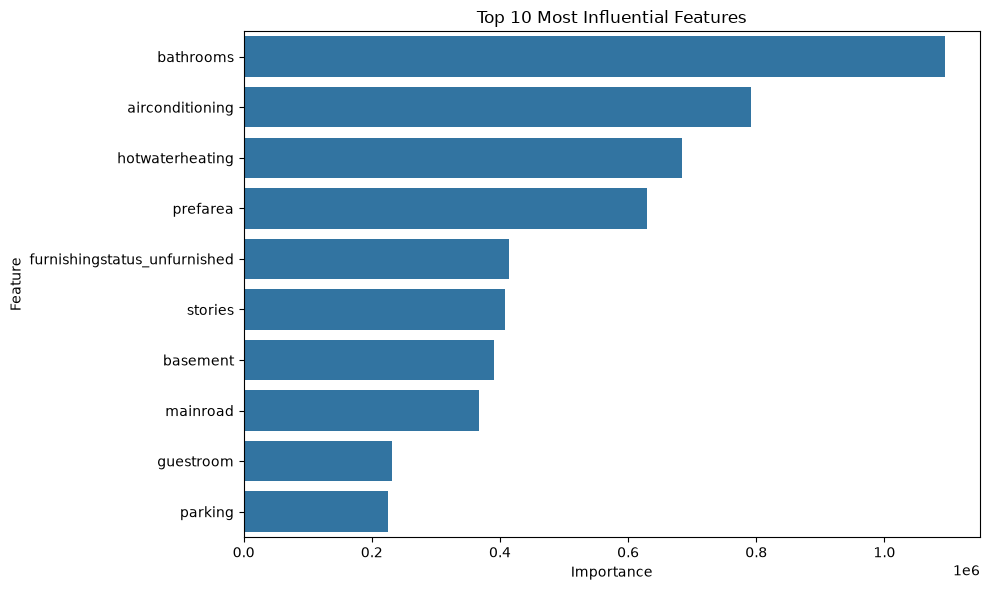

In [39]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Influential Features")

plt.tight_layout()

plt.savefig("charts/feature_importance.png", dpi=300)

plt.show()

In [40]:
feature_importance.head(10)

,Feature,Importance
2,bathrooms,1.094445e+06
8,airconditioning,7.914267e+05
7,hotwaterheating,6.846499e+05
10,prefarea,6.298906e+05
12,furnishingstatus_unfurnished,4.136451e+05
3,stories,4.074766e+05
6,basement,3.902512e+05
4,mainroad,3.679199e+05
5,guestroom,2.316100e+05
9,parking,2.248419e+05


## Task 5: Insights and Summary

### Key Findings

The analysis showed that bathrooms, air conditioning, hot water heating, preferred area, and furnishing status were among the most influential factors affecting house prices. Properties with more bathrooms and premium amenities generally had higher prices.

The Linear Regression model achieved an R² score of 0.653, meaning it was able to explain approximately 65.3% of the variation in house prices. Surprisingly, the Linear Regression model outperformed the Random Forest model, indicating that the relationship between the selected features and house prices is relatively linear.

The dataset contained no missing values or duplicate records, which simplified the preprocessing stage. One interesting observation was that amenities such as air conditioning and hot water heating had a stronger influence on price than expected.

Based on these findings, real estate businesses should emphasize property amenities and location-related features in their pricing strategies and marketing efforts, as these factors significantly impact house values.

In [ ]:
# saving the model
# Future Enhancement

#The trained Linear Regression model has been saved using Pickle. This allows the model to be reused in future applications such as web-based property valuation systems, real estate analytics dashboards, or Streamlit deployments without retraining.
import os
import pickle

os.makedirs("models", exist_ok=True)

with open("models/house_price_model.pkl", "wb") as file:
    pickle.dump(lr_model, file)

print("Model saved successfully!")

Model saved successfully!


In [43]:
with open("models/house_price_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully!")

Model loaded successfully!
